# Empirical Project: Age and Market Value in Professional Football

## Research Question
How is a professional football player's age related to their market value over time?

## Motivation
This project studies whether market value changes systematically as players get older. In contrast to a purely cross-sectional approach, this notebook uses repeated market value observations for the same player over time. This allows both a direct within-player comparison and an average comparison across age groups.

## Empirical Strategy
The analysis proceeds in two ways:
1. A panel-style analysis compares the same player over time.
2. A descriptive comparison examines average market values across age groups.

In addition, regression models are estimated to analyze whether the relationship between age and market value is linear or non-linear.

## Import Libraries

The following libraries are used for data handling, visualization, and econometric analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)

## Load Data

The analysis uses three datasets:
- `players.csv` for player characteristics
- `player_valuations.csv` for repeated market value observations over time
- `appearances.csv` for performance-related control variables such as goals, assists, and minutes played

In [3]:
players = pd.read_csv("Football_data/players.csv")
valuations = pd.read_csv("Football_data/player_valuations.csv")
appearances = pd.read_csv("Football_data/appearances.csv")

## Data Overview

This section provides an initial overview of the structure of the datasets and the variables relevant for the analysis.

In [4]:
print("Players shape:", players.shape)
print("Valuations shape:", valuations.shape)
print("Appearances shape:", appearances.shape)

print("\nPlayers columns:")
print(players.columns.tolist())

print("\nValuations columns:")
print(valuations.columns.tolist())

print("\nAppearances columns:")
print(appearances.columns.tolist())

Players shape: (47702, 26)
Valuations shape: (616377, 6)
Appearances shape: (1862208, 13)

Players columns:
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Valuations columns:
['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']

Appearances columns:
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']


## Data Preparation

Relevant variables are selected and date variables are converted into a proper datetime format. The player's age is calculated for each market valuation date.

In [5]:
players_clean = players[[
    "player_id",
    "name",
    "date_of_birth",
    "position",
    "sub_position",
    "current_club_name",
    "country_of_citizenship",
    "highest_market_value_in_eur"
]].copy()

valuations_clean = valuations[[
    "player_id",
    "date",
    "market_value_in_eur",
    "current_club_name",
    "player_club_domestic_competition_id"
]].copy()

players_clean["date_of_birth"] = pd.to_datetime(players_clean["date_of_birth"], errors="coerce")
valuations_clean["date"] = pd.to_datetime(valuations_clean["date"], errors="coerce")

## Merge Datasets and Construct Age

The valuation data is merged with player information. Age is calculated as the difference between valuation date and date of birth.

In [6]:
panel_df = valuations_clean.merge(
    players_clean,
    on="player_id",
    how="left"
)

panel_df["age"] = (panel_df["date"] - panel_df["date_of_birth"]).dt.days / 365.25
panel_df["age_squared"] = panel_df["age"] ** 2
panel_df["valuation_year"] = panel_df["date"].dt.year

print(panel_df[["player_id", "name", "date", "date_of_birth", "age", "market_value_in_eur"]].head())

   player_id            name       date date_of_birth        age  \
0     405973  Fadel Gobitaka 2000-01-20    1998-01-16   2.009582   
1     342216  Julien Serrano 2001-07-20    1998-02-13   3.430527   
2       3132   Florin Cernat 2003-12-09    1980-03-10  23.748118   
3       6893   Gabriel Tamas 2003-12-15    1983-11-09  20.098563   
4         10  Miroslav Klose 2004-10-04    1978-06-09  26.321697   

   market_value_in_eur  
0               150000  
1               100000  
2               400000  
3               900000  
4              7000000  


## Construct Performance Controls

To better isolate the relationship between age and market value, performance-related control variables are added. The appearance data is aggregated by player and year to obtain total goals, assists, and minutes played.

In [7]:
appearances_clean = appearances[[
    "player_id",
    "date",
    "goals",
    "assists",
    "minutes_played"
]].copy()

appearances_clean["date"] = pd.to_datetime(appearances_clean["date"], errors="coerce")
appearances_clean["valuation_year"] = appearances_clean["date"].dt.year

performance_yearly = (
    appearances_clean
    .groupby(["player_id", "valuation_year"], as_index=False)
    .agg({
        "goals": "sum",
        "assists": "sum",
        "minutes_played": "sum"
    })
)

print(performance_yearly.head())

   player_id  valuation_year  goals  assists  minutes_played
0         10            2012     11        1            1483
1         10            2013      9        4            2052
2         10            2014      8        6            1766
3         10            2015     12        8            2429
4         10            2016      8        6            1078


## Merge Performance Controls

The yearly performance data is merged into the panel dataset using player ID and year.

In [8]:
panel_df = panel_df.merge(
    performance_yearly,
    on=["player_id", "valuation_year"],
    how="left"
)

panel_df["goals"] = panel_df["goals"].fillna(0)
panel_df["assists"] = panel_df["assists"].fillna(0)
panel_df["minutes_played"] = panel_df["minutes_played"].fillna(0)

## Final Sample Restrictions

Observations with missing or implausible values are excluded. The final sample includes only observations with valid age and positive market value.

In [9]:
panel_df = panel_df.dropna(subset=["age", "market_value_in_eur", "position"])
panel_df = panel_df[panel_df["market_value_in_eur"] > 0]
panel_df = panel_df[(panel_df["age"] >= 15) & (panel_df["age"] <= 45)]

panel_df["log_market_value"] = np.log(panel_df["market_value_in_eur"])

print("Final panel shape:", panel_df.shape)
print(panel_df[["name", "date", "age", "market_value_in_eur", "goals", "assists", "minutes_played"]].head())

Final panel shape: (614182, 19)
                 name       date        age  market_value_in_eur  goals  \
2       Florin Cernat 2003-12-09  23.748118               400000    0.0   
3       Gabriel Tamas 2003-12-15  20.098563               900000    0.0   
4      Miroslav Klose 2004-10-04  26.321697              7000000    0.0   
5  Roman Weidenfeller 2004-10-04  24.161533              1500000    0.0   
6    Dimitar Berbatov 2004-10-04  23.676934              8000000    0.0   

   assists  minutes_played  
2      0.0             0.0  
3      0.0             0.0  
4      0.0             0.0  
5      0.0             0.0  
6      0.0             0.0  


## Descriptive Statistics

This section reports summary statistics for the main variables used in the empirical analysis.

In [10]:
summary_stats = panel_df[[
    "age",
    "market_value_in_eur",
    "log_market_value",
    "goals",
    "assists",
    "minutes_played"
]].describe()

print(summary_stats)

                 age  market_value_in_eur  log_market_value          goals  \
count  614182.000000         6.141820e+05     614182.000000  614182.000000   
mean       25.234566         2.339544e+06         13.304052       0.707590   
std         4.571692         6.777237e+06          1.544420       2.351203   
min        15.000684         1.000000e+04          9.210340       0.000000   
25%        21.612594         2.000000e+05         12.206073       0.000000   
50%        24.676249         5.000000e+05         13.122363       0.000000   
75%        28.364134         1.500000e+06         14.220976       0.000000   
max        44.898015         2.000000e+08         19.113828      59.000000   

             assists  minutes_played  
count  614182.000000   614182.000000  
mean        0.549689      487.150379  
std         1.620369      870.948814  
min         0.000000        0.000000  
25%         0.000000        0.000000  
50%         0.000000        0.000000  
75%         0.000000    

## Distribution of Age

This figure shows the distribution of player age in the estimation sample. Since age is the main explanatory variable in the empirical analysis, it is important to understand whether the sample is concentrated around certain age ranges or broadly spread across the career cycle.

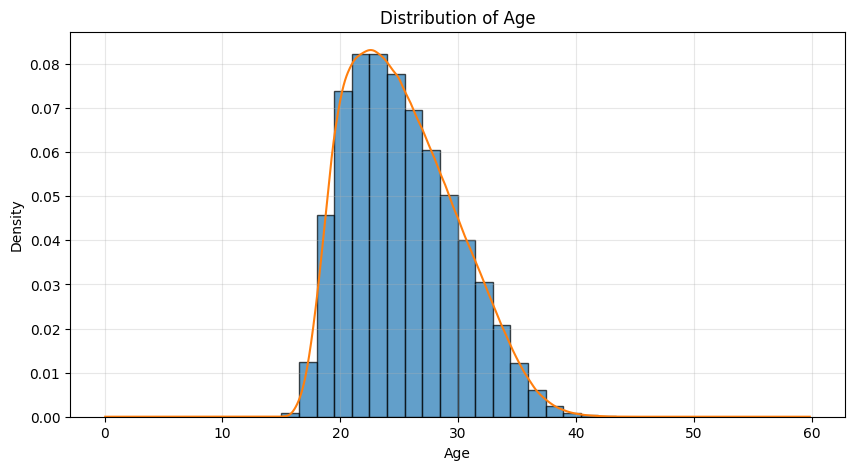

In [11]:
plt.figure(figsize=(10, 5))
panel_df["age"].plot(kind="hist", bins=20, density=True, alpha=0.7, edgecolor="black")
panel_df["age"].plot(kind="density")

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Distribution of Age")
plt.grid(alpha=0.3)
plt.show()

## Distribution of Market Value

Market values are usually strongly right-skewed, because a small number of players are worth substantially more than the average player. For this reason, it is useful to examine the distribution of the logarithm of market value, which is also the dependent variable used in the regression models.

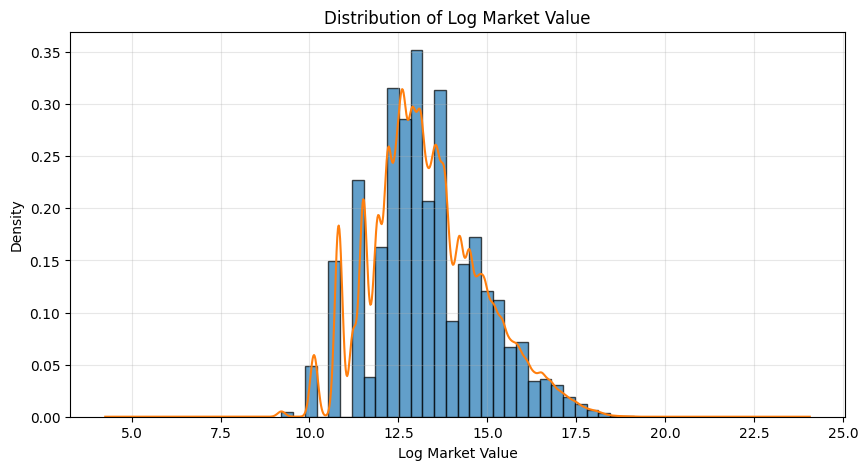

In [23]:
plt.figure(figsize=(10, 5))
panel_df["log_market_value"].plot(kind="hist", bins=30, density=True, alpha=0.7, edgecolor="black")
panel_df["log_market_value"].plot(kind="density")

plt.xlabel("Log Market Value")
plt.ylabel("Density")
plt.title("Distribution of Log Market Value")
plt.grid(alpha=0.3)
plt.show()

## Relationship Between Age and Market Value

The next figures provide descriptive evidence on the relationship between age and player market value. The scatter plot shows the raw association between age and log market value at the individual observation level. In addition, a quadratic fit is added to reflect the empirical specification used later in the regression analysis, where both age and age squared are included.

The box plot complements this analysis by showing how the distribution of log market value differs across broader age groups. This helps identify not only differences in average value, but also variation, medians, and potential outliers within each age category.

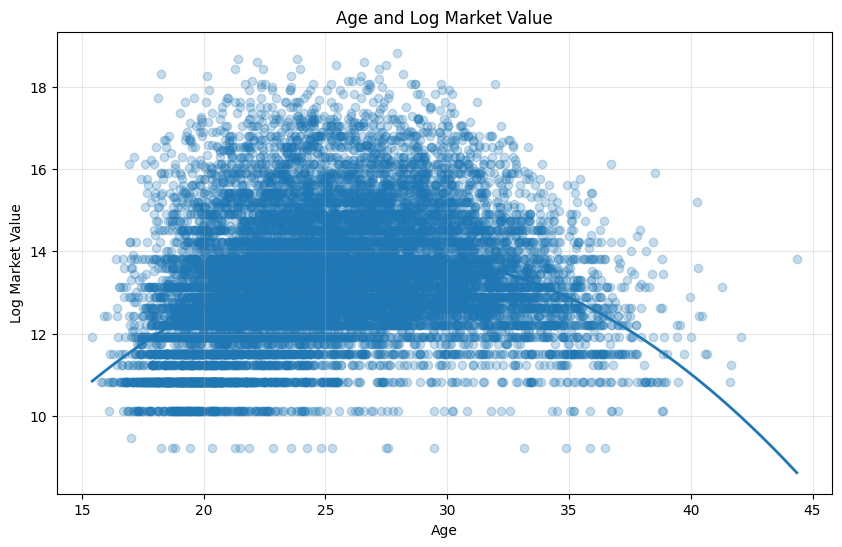

/tmp/ipykernel_2952/338250755.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=age_labels, patch_artist=False)


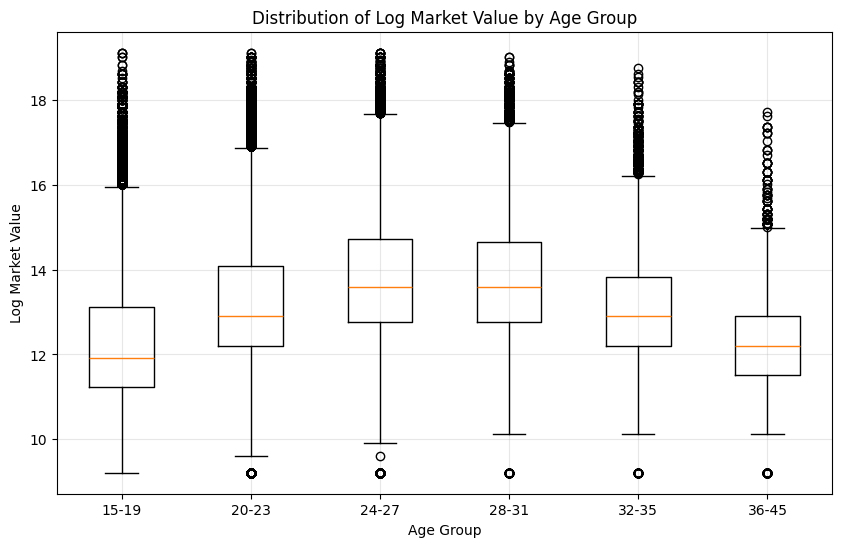

In [24]:
# Scatter plot: Age vs. log(Market Value) with quadratic fit
plot_df = panel_df[["age", "log_market_value"]].dropna().copy()

# Optional: reduce overplotting if the dataset is very large
if len(plot_df) > 15000:
    plot_df = plot_df.sample(15000, random_state=42)

# Quadratic fit
x = plot_df["age"]
y = plot_df["log_market_value"]
coeffs = np.polyfit(x, y, 2)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = np.polyval(coeffs, x_fit)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_fit, y_fit, linewidth=2)

plt.xlabel("Age")
plt.ylabel("Log Market Value")
plt.title("Age and Log Market Value")
plt.grid(alpha=0.3)
plt.show()


# Box plot by age group
age_bins = [15, 20, 24, 28, 32, 36, 46]
age_labels = ["15-19", "20-23", "24-27", "28-31", "32-35", "36-45"]

box_df = panel_df.copy()
box_df["age_group"] = pd.cut(
    box_df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

box_data = [
    box_df.loc[box_df["age_group"] == group, "log_market_value"].dropna()
    for group in age_labels
]

plt.figure(figsize=(10, 6))
plt.boxplot(box_data, labels=age_labels, patch_artist=False)

plt.xlabel("Age Group")
plt.ylabel("Log Market Value")
plt.title("Distribution of Log Market Value by Age Group")
plt.grid(alpha=0.3)
plt.show()

## Within-Player Comparison Over Time

To directly compare the same player over time, the market value trajectories of selected players are visualized. This illustrates how market value changes as players get older.

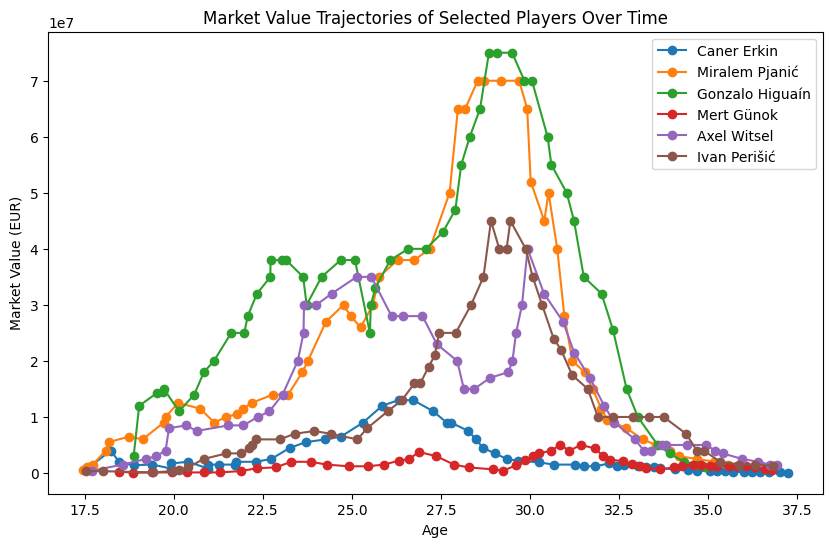

In [12]:
# Spieler mit den meisten Marktwert-Beobachtungen auswählen
top_players = (
    panel_df.groupby(["player_id", "name"])
    .size()
    .reset_index(name="n_obs")
    .sort_values("n_obs", ascending=False)
    .head(6)
)

top_player_ids = top_players["player_id"].tolist()

plot_df = panel_df[panel_df["player_id"].isin(top_player_ids)].copy()

plt.figure(figsize=(10, 6))
for pid in top_player_ids:
    temp = plot_df[plot_df["player_id"] == pid].sort_values("age")
    plt.plot(temp["age"], temp["market_value_in_eur"], marker="o", label=temp["name"].iloc[0])

plt.xlabel("Age")
plt.ylabel("Market Value (EUR)")
plt.title("Market Value Trajectories of Selected Players Over Time")
plt.legend()
plt.show()

## Average Market Value by Age

This section compares average market values across ages in order to identify whether market values tend to increase and later decline over the life cycle of a professional player.

In [13]:
avg_by_age = (
    panel_df.groupby(panel_df["age"].round())["market_value_in_eur"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"age": "rounded_age"})
)

print(avg_by_age.head())

   rounded_age           mean    median  count
0         15.0   64583.333333   50000.0     24
1         16.0  591578.608247   75000.0    776
2         17.0  716316.334356  100000.0   5216
3         18.0  845433.194218  100000.0  16533
4         19.0  998405.441459  150000.0  32234


## Average Market Value by Age

The plot shows that average market value increases with age, reaches a peak in the mid-20s, and declines afterwards. This pattern suggests a non-linear relationship between age and market value over the career cycle.

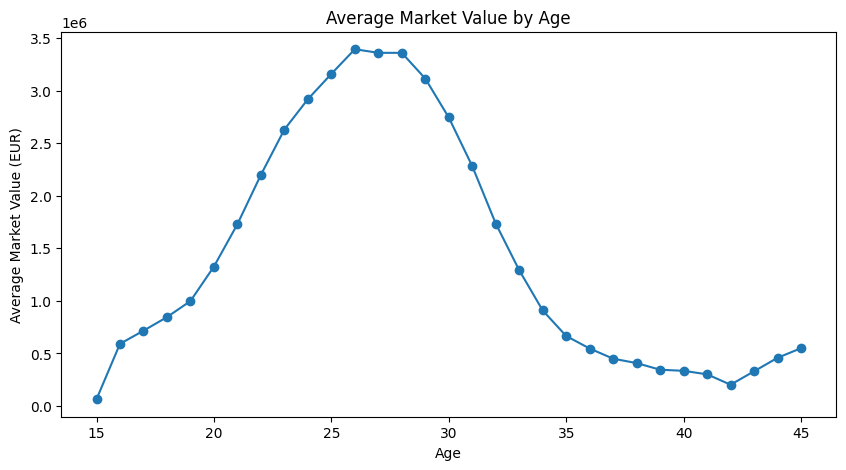

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(avg_by_age["rounded_age"], avg_by_age["mean"], marker="o")
plt.xlabel("Age")
plt.ylabel("Average Market Value (EUR)")
plt.title("Average Market Value by Age")
plt.show()

## Median Market Value by Age

The plot shows that median market value increases with age, peaks in the mid-20s, and declines afterwards. Using the median reduces the influence of extreme values and confirms the non-linear relationship between age and market value.

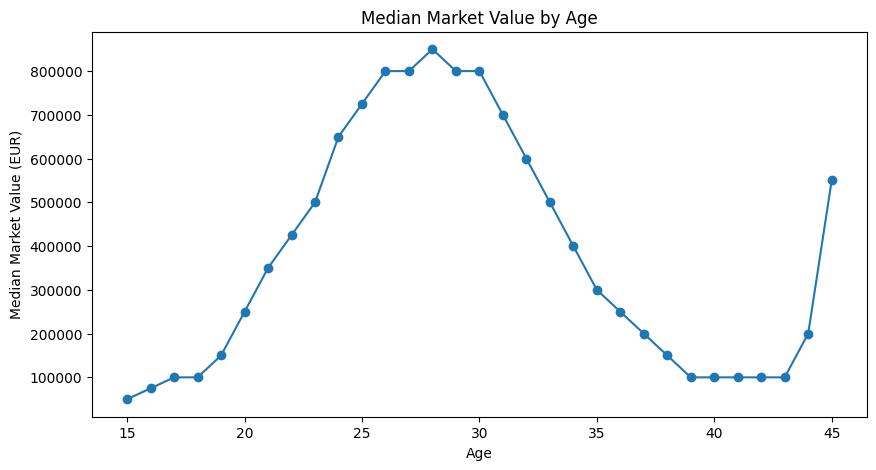

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(avg_by_age["rounded_age"], avg_by_age["median"], marker="o")
plt.xlabel("Age")
plt.ylabel("Median Market Value (EUR)")
plt.title("Median Market Value by Age")
plt.show()

## Age Group Comparison

In addition to single-age averages, players are grouped into broader age categories. This allows a direct comparison between younger and older players in terms of mean and median market value.

In [16]:
age_bins = [15, 20, 24, 28, 32, 36, 46]
age_labels = ["15-19", "20-23", "24-27", "28-31", "32-35", "36-45"]

panel_df["age_group"] = pd.cut(panel_df["age"], bins=age_bins, labels=age_labels, right=False)

age_group_stats = (
    panel_df.groupby("age_group")["market_value_in_eur"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print(age_group_stats)

  age_group          mean    median   count
0     15-19  1.014976e+06  150000.0   75726
1     20-23  2.181160e+06  400000.0  198910
2     24-27  3.263557e+06  800000.0  173194
3     28-31  2.760938e+06  800000.0  110455
4     32-35  1.104186e+06  400000.0   47273
5     36-45  4.412129e+05  200000.0    8624


## Average Market Value by Age Group

The bar chart shows that average market value rises with age, peaks in the mid-20s, and declines thereafter. This pattern reflects the typical player career cycle and suggests a non-linear relationship between age and market value.

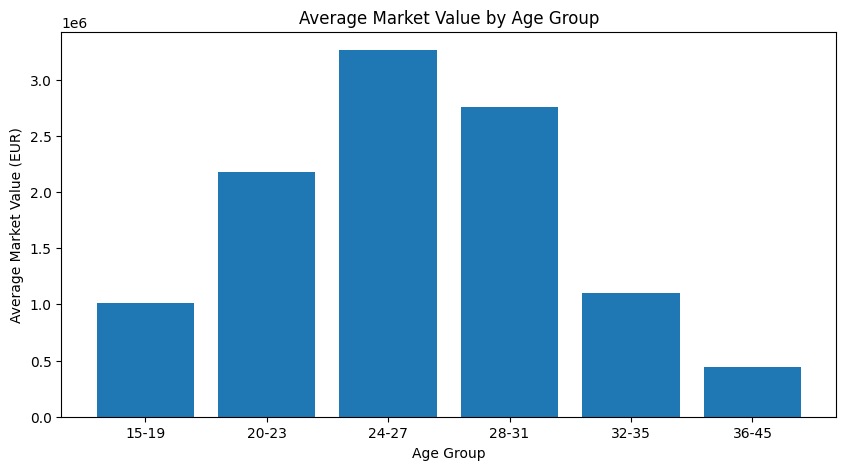

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(age_group_stats["age_group"].astype(str), age_group_stats["mean"])
plt.xlabel("Age Group")
plt.ylabel("Average Market Value (EUR)")
plt.title("Average Market Value by Age Group")
plt.show()

## Baseline Regression

A baseline OLS model is estimated to examine the relationship between age and market value. A quadratic age term is included to allow for a non-linear life-cycle pattern.

In [18]:
model_1 = smf.ols(
    "log_market_value ~ age + age_squared",
    data=panel_df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                 4.524e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:03:36   Log-Likelihood:            -1.0962e+06
No. Observations:              614182   AIC:                         2.192e+06
Df Residuals:                  614179   BIC:                         2.193e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.4992      0.051    -29.314      

## Interpretation of the Baseline Model

The baseline regression shows a positive coefficient on age and a negative coefficient on age squared. This indicates a non-linear relationship between age and market value, consistent with an inverted U-shape.

In economic terms, player market value tends to increase at younger ages, reaches a peak during the prime phase of a player's career, and declines at older ages.

## Extended Regression with Controls

An extended model includes player position, league, performance, and year effects. These controls help isolate the relationship between age and market value more clearly.

In [19]:
model_2 = smf.ols(
    "log_market_value ~ age + age_squared + goals + assists + minutes_played + C(position) + C(player_club_domestic_competition_id) + C(valuation_year)",
    data=panel_df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     9953.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:03:48   Log-Likelihood:            -8.0124e+05
No. Observations:              542998   AIC:                         1.603e+06
Df Residuals:                  542934   BIC:                         1.603e+06
Df Model:                          63                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

Compared with the baseline model, the extended specification controls for important observable differences across players and years. This is important because market value is also affected by player role, performance, league quality, and broader market conditions.

## Within-Player Analysis

To compare the same player over time, a within-player transformation is used. This removes all time-invariant player characteristics and focuses only on changes within a player over time.

In [20]:
fe_vars = ["log_market_value", "age", "age_squared", "goals", "assists", "minutes_played"]

fe_df = panel_df[["player_id", "valuation_year"] + fe_vars].dropna().copy()

for var in fe_vars:
    fe_df[f"{var}_mean_player"] = fe_df.groupby("player_id")[var].transform("mean")
    fe_df[f"{var}_dm"] = fe_df[var] - fe_df[f"{var}_mean_player"]

print(fe_df.head())

   player_id  valuation_year  log_market_value        age  age_squared  goals  \
2       3132            2003         12.899220  23.748118   563.973096    0.0   
3       6893            2003         13.710150  20.098563   403.952220    0.0   
4         10            2004         15.761421  26.321697   692.831758    0.0   
5         26            2004         14.220976  24.161533   583.779686    0.0   
6         65            2004         15.894952  23.676934   560.597185    0.0   

   assists  minutes_played  log_market_value_mean_player  log_market_value_dm  \
2      0.0             0.0                     13.446615            -0.547395   
3      0.0             0.0                     13.615112             0.095038   
4      0.0             0.0                     15.583770             0.177651   
5      0.0             0.0                     14.937422            -0.716446   
6      0.0             0.0                     16.172051            -0.277099   

   age_mean_player     age

## Fixed Effects Model

To account for unobserved player-specific characteristics, a fixed effects (FE) model is estimated using the within transformation (demeaning approach). This method removes all time-invariant individual heterogeneity, allowing the analysis to focus on variation within players over time.

The dependent variable is the logarithm of market value. The key explanatory variables include age and age squared, capturing the non-linear relationship between age and market value. In addition, performance-related controls such as goals, assists, and minutes played are included in the model.

By using the demeaned variables (indicated by the suffix "_dm"), the estimation effectively controls for all constant player-specific factors, such as innate talent or long-term reputation, which could otherwise bias the results.

The estimated coefficients therefore reflect how changes in a player's age and performance over time are associated with changes in their market value.

In [21]:
X_fe = fe_df[["age_dm", "age_squared_dm", "goals_dm", "assists_dm", "minutes_played_dm"]]
y_fe = fe_df["log_market_value_dm"]

fe_model = sm.OLS(y_fe, X_fe).fit()
print(fe_model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     log_market_value_dm   R-squared (uncentered):                   0.450
Model:                             OLS   Adj. R-squared (uncentered):              0.450
Method:                  Least Squares   F-statistic:                          1.007e+05
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):                        0.00
Time:                         10:03:48   Log-Likelihood:                     -6.2668e+05
No. Observations:               614182   AIC:                                  1.253e+06
Df Residuals:                   614177   BIC:                                  1.253e+06
Df Model:                            5                                                  
Covariance Type:             nonrobust                                                  
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------

This model focuses on within-player variation only. In other words, it asks whether a player's market value changes systematically as that same player gets older, holding constant all time-invariant player characteristics.

## Estimated Peak Age

The turning point of the quadratic model is calculated to estimate the age at which market value reaches its peak.

In [22]:
beta_age = model_2.params["age"]
beta_age_sq = model_2.params["age_squared"]

turning_point = -beta_age / (2 * beta_age_sq)
print("Estimated peak age:", turning_point)

Estimated peak age: 27.424174453599132


The turning point indicates the approximate age at which market value is predicted to reach its maximum before declining again.

## Interpretation

The descriptive results and regression models together provide evidence on the relationship between age and market value. The age profiles and age-group comparisons show whether younger and older players differ systematically in average market value. The within-player analysis goes one step further by comparing the same player over time.

If the coefficient on age is positive and the coefficient on age squared is negative, the relationship is consistent with an inverted U-shape: market value rises during the early and mid-career phase and declines at older ages.

The within-player model is especially important because it reduces bias from time-invariant player characteristics. However, the results should still be interpreted as associations rather than strict causal effects.

## Limitations

This analysis has several limitations. First, the estimated relationships should not be interpreted as causal effects. Market value depends on many additional factors such as injuries, contract length, reputation, transfer rumors, and international visibility. Second, yearly performance controls may not perfectly match the exact valuation date. Third, market values are not directly observed transaction prices, but estimated values. Finally, some relevant controls may still be missing, which can lead to omitted variable bias.

## Conclusion

This project examined the relationship between age and market value in professional football using repeated market value observations over time. The analysis combined two approaches: a direct within-player comparison over time and an average comparison across ages and age groups.

The results make it possible to assess whether market value follows a life-cycle pattern. In addition, the within-player analysis provides a more convincing way to study the role of age, since it compares the same player over time rather than only comparing different players at one point in time.

Overall, this framework is well suited to analyze whether market value tends to increase early in a player's career, peak at a certain age, and decline afterwards.